#### Bit depth

This is a small notebook that generates a figure which illustrates the relevance of bith depth.

In [52]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Generate a time series which varies ±5 around a value of 10
time_1 = np.arange(0, 100)
value_1 = 10 + 5 * np.sin(0.2 * time_1) + np.random.normal(0, .5, size=time_1.shape) 

# Now generate a 2nd time series which varies ±1000 around a value of 10.000
time_2 = np.arange(100, 200)
value_2 = 10000 + 1000 * np.sin(0.2 * time_2) + np.random.normal(0, 100, size=time_2.shape)

# Paste together the two respective signals
time = np.concatenate([time_1, time_2])
value = np.concatenate([value_1, value_2])

# Normalize value such that max = 255
# value = (value - value.min()) / (value.max() - value.min()) * 255

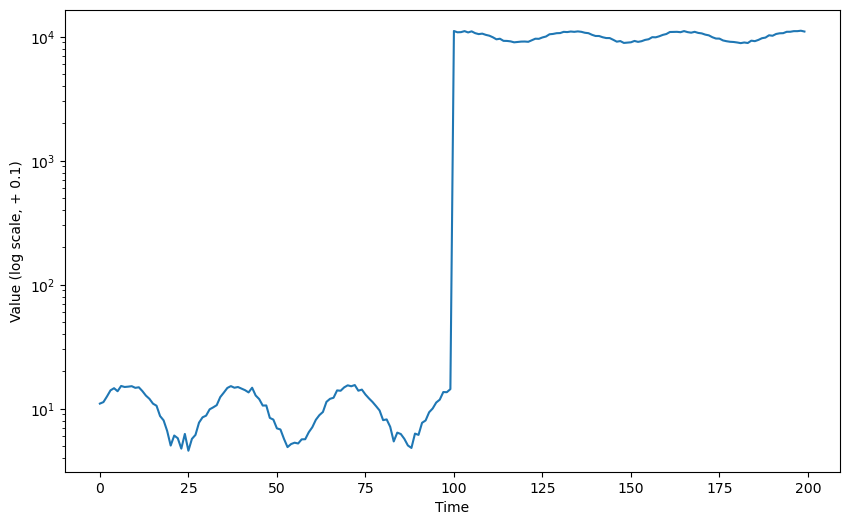

In [53]:
# Now plot on a logarithmic y-axis
def plot_mydata(time, value, ax):
    ax.plot(time, value+.1, label='Time Series Data')
    ax.set_yscale('log')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value (log scale, + 0.1)')
    
# Generate figure
fig, ax = plt.subplots(figsize=(10, 6))
plot_mydata(time, value, ax)

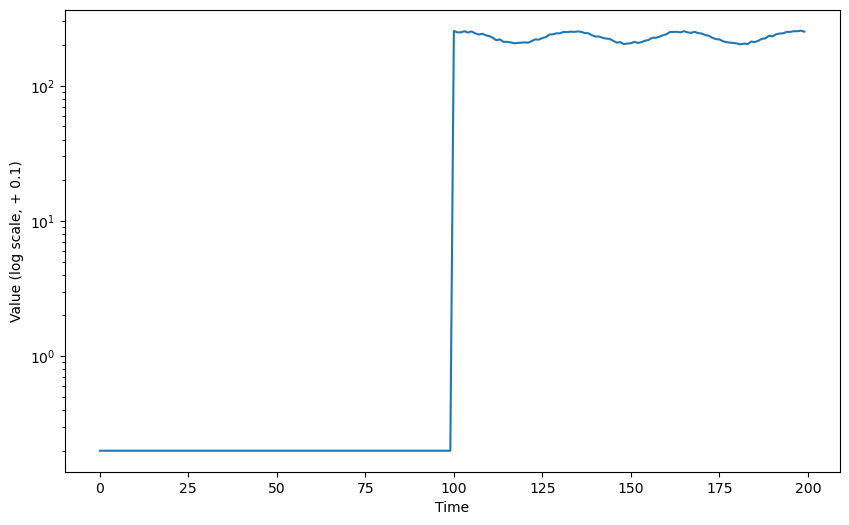

In [54]:
value_as_8bitint = np.clip(np.round((value - value.min()) / (value.max() - value.min()) * 255), 0, 255).astype(np.uint8)

# Now make the same plot again
fig, ax = plt.subplots(figsize=(10, 6))
plot_mydata(time, value_as_8bitint+.1, ax)

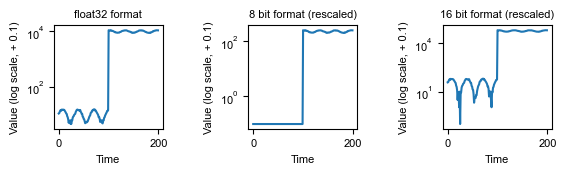

In [56]:
# Also convert to 16 bit int
value_as_16bitint = np.clip(np.round((value - value.min()) / (value.max() - value.min()) * 65535), 0, 65535).astype(np.uint16)

# piece of code to set fonts to arial 8
def set_fonts(axs):
    for ax in axs:
        for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                    ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(8)
            item.set_fontname('Arial')

# now arrange those two figures next to each other
fig, axs = plt.subplots(1, 3, figsize=(15/2.54, 5/2.54))
plot_mydata(time, value, axs[0])
axs[0].set_title("float32 format")
plot_mydata(time, value_as_8bitint, axs[1])
axs[1].set_title("8 bit format (rescaled)")
plot_mydata(time, value_as_16bitint, axs[2])
axs[2].set_title("16 bit format (rescaled)")
plt.tight_layout()
set_fonts(axs)
# save to pdf on desktop
fig.savefig("/Users/m.wehrens/Desktop/regarding_bit_depth.pdf", dpi=300)

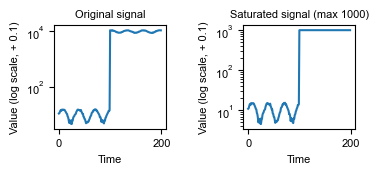

In [59]:
# Now emulate saturation of the signal

# let's say for the original signal, 1000 falls outside the sensor range
value_saturated = np.copy(value)
value_saturated[value_saturated > 1000] = 1000

# now compare original value and saturated in plot
fig, axs = plt.subplots(1, 2, figsize=(10/2.54, 5/2.54))
plot_mydata(time, value, axs[0])
axs[0].set_title("Original signal")
plot_mydata(time, value_saturated, axs[1])
axs[1].set_title("Saturated signal (max 1000)")
plt.tight_layout()
set_fonts(axs)
# save
fig.savefig("/Users/m.wehrens/Desktop/regarding_saturation.pdf", dpi=300)
